# Notebook 6 : QuantFormer Model Evaluation

## Objective

This notebook evaluates the trained QuantFormer model on the FI-2010
Level-2 Limit Order Book test dataset.

The evaluation includes:

- Loading the best trained model
- Running inference on unseen test data
- Computing evaluation metrics
- Visualizing performance
- Saving evaluation artifacts

The goal is to assess the model's generalization ability and analyze
its predictions using quantitative metrics and visualizations.

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import numpy as np

import torch

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from src.config import *

from src.data.dataset import FI2010Dataset

from src.models.tft_model import (
    TemporalFusionTransformer
)

from src.training.evaluation import (
    evaluate_predictions
)

In [3]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)

print(f"Using Device : {DEVICE}")

print("=" * 60)

Using Device : cpu


In [4]:
print("Sequence Length :", SEQUENCE_LENGTH)

print("Features        :", NUM_FEATURES)

print("Hidden Size     :", HIDDEN_SIZE)

print("Classes         :", NUM_CLASSES)

print("Batch Size      :", BATCH_SIZE)

Sequence Length : 100
Features        : 143
Hidden Size     : 128
Classes         : 3
Batch Size      : 128


# Section 2 : Load Test Dataset

## Objective

In this section, we load the preprocessed FI-2010 test dataset that was
generated during data preprocessing.

The dataset consists of:

- Test feature sequences
- Test labels

These samples will be converted into a PyTorch Dataset and DataLoader
for efficient batch-wise evaluation.

In [7]:
DATA_DIR = "../datasets/processed/FI2010"

X_test = np.load(
    os.path.join(DATA_DIR, "X_test.npy")
)

y_test = np.load(
    os.path.join(DATA_DIR, "y_test.npy")
)

print("=" * 60)
print("Test Dataset Loaded Successfully")
print("=" * 60)

Test Dataset Loaded Successfully


In [8]:
print(f"X_test Shape : {X_test.shape}")

print(f"y_test Shape : {y_test.shape}")

print()

print(f"Sequence Length : {X_test.shape[1]}")

print(f"Features        : {X_test.shape[2]}")

print(f"Classes         : {len(np.unique(y_test))}")

X_test Shape : (31838, 100, 143)
y_test Shape : (31838,)

Sequence Length : 100
Features        : 143
Classes         : 3


In [9]:
test_dataset = FI2010Dataset(
    X_test,
    y_test
)


print("PyTorch Dataset Created")

print("Total Samples :", len(test_dataset))



PyTorch Dataset Created
Total Samples : 31838


In [10]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Test DataLoader Created")

print("Total Batches :", len(test_loader))


Test DataLoader Created
Total Batches : 249


In [11]:
features, labels = next(iter(test_loader))

print("Feature Batch Shape :", features.shape)

print("Label Batch Shape   :", labels.shape)

print()

print("Feature dtype :", features.dtype)

print("Label dtype   :", labels.dtype)

Feature Batch Shape : torch.Size([128, 100, 143])
Label Batch Shape   : torch.Size([128])

Feature dtype : torch.float32
Label dtype   : torch.int64


# Section 3 : Load Trained QuantFormer Model

## Objective

In this section, we restore the best QuantFormer model that was saved
during training.

The model is loaded from the checkpoint directory and moved to the
appropriate computation device (CPU/GPU).

Once loaded, the model is switched to evaluation mode to disable
dropout and gradient computation before performing inference on the
test dataset.

In [12]:
CHECKPOINT_PATH = "../checkpoints/best_tft_model.pth"

print("Checkpoint Path")
print(CHECKPOINT_PATH)

Checkpoint Path
../checkpoints/best_tft_model.pth


In [13]:
if os.path.exists(CHECKPOINT_PATH):
    print("✅ Model checkpoint found.")
else:
    raise FileNotFoundError(
        f"Checkpoint not found:\n{CHECKPOINT_PATH}"
    )

✅ Model checkpoint found.


In [14]:
model = TemporalFusionTransformer()

print(model.__class__.__name__)

TemporalFusionTransformer


In [17]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

model.eval()

print("✅ QuantFormer Loaded Successfully")

✅ QuantFormer Loaded Successfully


In [18]:
features, labels = next(iter(test_loader))

features = features.to(DEVICE)

with torch.no_grad():

    logits, attention = model(features)

print("Logits Shape    :", logits.shape)

print("Attention Shape :", attention.shape)

Logits Shape    : torch.Size([128, 3])
Attention Shape : torch.Size([128, 4, 100, 100])


# Section 4 : Model Inference

## Objective

This section performs inference on the complete FI-2010 test dataset.

The trained QuantFormer model predicts the next price movement for each
test sequence.

The predictions and ground-truth labels are collected for evaluation in
the following sections.

In [20]:
# ==========================================================
# Run Model Inference
# ==========================================================

model.eval()

all_predictions = []

all_labels = []

all_probabilities = []

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(DEVICE)

        labels = labels.to(DEVICE)

        logits, attention = model(features)

        probabilities = torch.softmax(logits, dim=1)

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

print("=" * 60)
print("Inference Completed Successfully")
print("=" * 60)

Inference Completed Successfully


In [21]:
all_predictions = np.array(all_predictions)

all_labels = np.array(all_labels)

all_probabilities = np.array(all_probabilities)

print("Predictions Shape :", all_predictions.shape)

print("Labels Shape      :", all_labels.shape)

print("Probabilities Shape :", all_probabilities.shape)

Predictions Shape : (31838,)
Labels Shape      : (31838,)
Probabilities Shape : (31838, 3)


In [22]:
print("First 10 Predictions:")

print(all_predictions[:10])

print()

print("First 10 Ground Truth Labels:")

print(all_labels[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Ground Truth Labels:
[0 0 0 0 0 0 0 0 0 2]


In [23]:
unique, counts = np.unique(
    all_predictions,
    return_counts=True
)

print("Prediction Distribution")

for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt}")

Prediction Distribution
Class 0: 12135
Class 1: 8575
Class 2: 11128


# Section 5 : Model Evaluation Metrics

## Objective

In this section, we evaluate the performance of the trained
QuantFormer model on the FI-2010 test dataset.

The following metrics are computed:

- Accuracy
- Precision
- Recall
- Macro F1-Score
- Classification Report

These metrics provide a quantitative assessment of the model's
classification performance across all three price movement classes.

In [25]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("Evaluation Metrics")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Macro F1  : {f1:.4f}")

Evaluation Metrics
Accuracy  : 0.8451
Precision : 0.8473
Recall    : 0.8461
Macro F1  : 0.8466


In [26]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=[
        "Down",
        "Stable",
        "Up"
    ],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

        Down       0.85      0.84      0.84     12205
      Stable       0.87      0.86      0.87      8733
          Up       0.82      0.84      0.83     10900

    accuracy                           0.85     31838
   macro avg       0.85      0.85      0.85     31838
weighted avg       0.85      0.85      0.85     31838



In [27]:
os.makedirs("../artifacts", exist_ok=True)

report_path = "../artifacts/classification_report.txt"

with open(report_path, "w") as f:
    f.write(report)

print("Classification report saved to:")
print(report_path)

Classification report saved to:
../artifacts/classification_report.txt


In [28]:
metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "macro_f1": float(f1)
}

import json

metrics_path = "../artifacts/evaluation_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

print("Evaluation metrics saved to:")
print(metrics_path)

Evaluation metrics saved to:
../artifacts/evaluation_metrics.json


# Section 6 : Confusion Matrix

## Objective

The confusion matrix provides a detailed visualization of the model's
classification performance by comparing predicted labels with the
ground-truth labels.

It helps identify which classes are classified correctly and where
misclassifications occur.

In [29]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[10264   589  1352]
 [  618  7491   624]
 [ 1253   495  9152]]


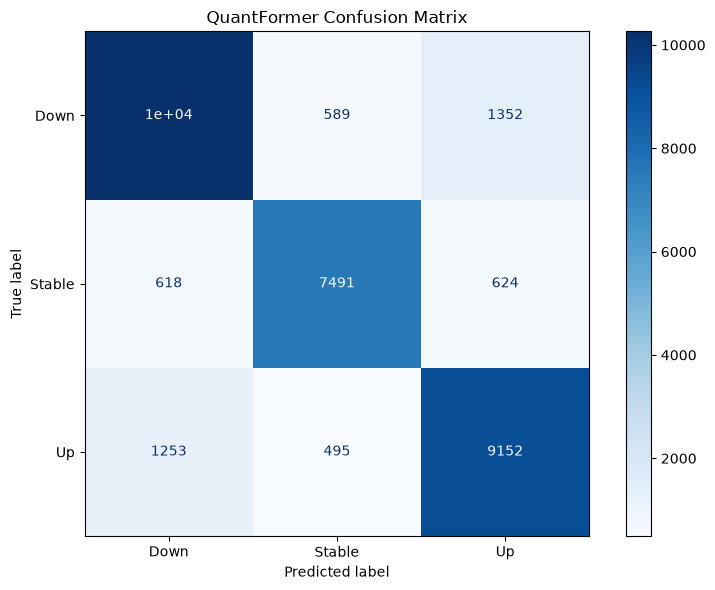

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Down",
        "Stable",
        "Up"
    ]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

plt.title("QuantFormer Confusion Matrix")

plt.tight_layout()

plt.show()

In [31]:
os.makedirs("../artifacts", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Down",
        "Stable",
        "Up"
    ]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

plt.title("QuantFormer Confusion Matrix")

plt.tight_layout()

save_path = "../artifacts/confusion_matrix.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Confusion matrix saved successfully!")

print(save_path)

Confusion matrix saved successfully!
../artifacts/confusion_matrix.png


In [32]:
print("Evaluation Summary")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Macro F1  : {f1:.4f}")

Evaluation Summary
Accuracy  : 0.8451
Precision : 0.8473
Recall    : 0.8461
Macro F1  : 0.8466


# Section 7 : Sample Predictions

## Objective

In this section, we inspect a few predictions made by the trained
QuantFormer model.

For each sample we compare:

- Ground Truth Label
- Predicted Label
- Prediction Probabilities

This provides an intuitive understanding of the model's behavior.

In [33]:
LABEL_MAP = {
    0: "Down",
    1: "Stable",
    2: "Up"
}

In [34]:
num_samples = 10

print("=" * 80)
print("Sample Predictions")
print("=" * 80)

for i in range(num_samples):

    true_label = LABEL_MAP[int(all_labels[i])]

    predicted_label = LABEL_MAP[int(all_predictions[i])]

    confidence = np.max(all_probabilities[i])

    print(f"Sample {i+1}")

    print(f"True Label      : {true_label}")

    print(f"Predicted Label : {predicted_label}")

    print(f"Confidence      : {confidence:.4f}")

    print("-" * 80)

Sample Predictions
Sample 1
True Label      : Down
Predicted Label : Down
Confidence      : 0.9868
--------------------------------------------------------------------------------
Sample 2
True Label      : Down
Predicted Label : Down
Confidence      : 0.9865
--------------------------------------------------------------------------------
Sample 3
True Label      : Down
Predicted Label : Down
Confidence      : 0.9961
--------------------------------------------------------------------------------
Sample 4
True Label      : Down
Predicted Label : Down
Confidence      : 0.9987
--------------------------------------------------------------------------------
Sample 5
True Label      : Down
Predicted Label : Down
Confidence      : 0.9993
--------------------------------------------------------------------------------
Sample 6
True Label      : Down
Predicted Label : Down
Confidence      : 0.9995
--------------------------------------------------------------------------------
Sample 7
True L

In [35]:

import pandas as pd

results = pd.DataFrame({

    "Ground Truth": [
        LABEL_MAP[int(i)] for i in all_labels[:20]
    ],

    "Prediction": [
        LABEL_MAP[int(i)] for i in all_predictions[:20]
    ],

    "Confidence": [
        np.max(prob) for prob in all_probabilities[:20]
    ]
    

})

results

,Ground Truth,Prediction,Confidence
0,Down,Down,0.986788
1,Down,Down,0.986521
2,Down,Down,0.996108
3,Down,Down,0.998656
4,Down,Down,0.999254
5,Down,Down,0.999541
6,Down,Down,0.999663
7,Down,Down,0.999451
8,Down,Down,0.998109
9,Up,Down,0.963069


In [36]:
results.to_csv(
    "../artifacts/sample_predictions.csv",
    index=False
)

print("Sample predictions saved successfully!")

print("../artifacts/sample_predictions.csv")

Sample predictions saved successfully!
../artifacts/sample_predictions.csv


# Section 8 : Attention Visualization

## Objective

The Temporal Fusion Transformer uses a Multi-Head Attention mechanism
to focus on the most informative time steps in the input sequence.

In this section, we visualize the attention weights learned by the
model to understand where it focuses while making predictions.

In [37]:
model.eval()

with torch.no_grad():

    features, labels = next(iter(test_loader))

    features = features.to(DEVICE)

    logits, attention = model(features)

print("Attention Shape :", attention.shape)

Attention Shape : torch.Size([128, 4, 100, 100])


In [38]:
attention_np = attention.detach().cpu().numpy()

print("Attention Tensor Shape:", attention_np.shape)

Attention Tensor Shape: (128, 4, 100, 100)


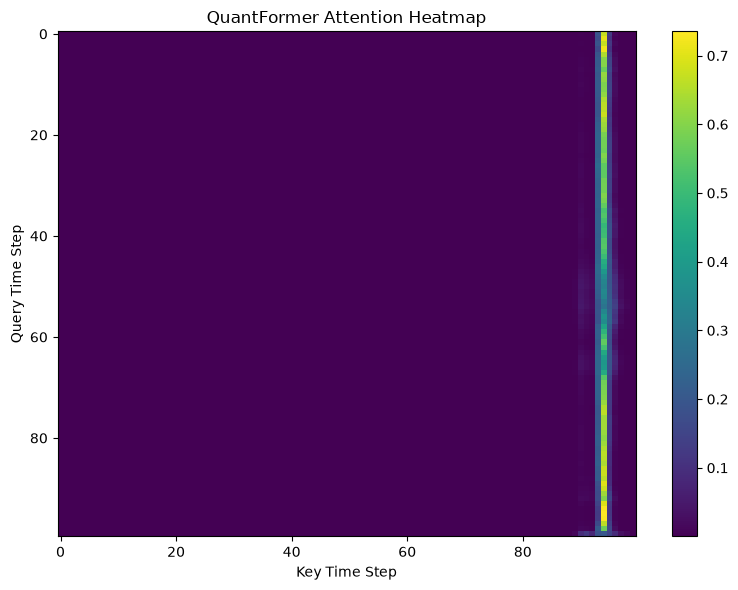

In [39]:
plt.figure(figsize=(8, 6))

if attention_np.ndim == 4:

    matrix = attention_np[0, 0]

elif attention_np.ndim == 3:

    matrix = attention_np[0]

else:

    raise ValueError(
        f"Unexpected attention shape: {attention_np.shape}"
    )

plt.imshow(
    matrix,
    cmap="viridis",
    aspect="auto"
)

plt.title("QuantFormer Attention Heatmap")

plt.xlabel("Key Time Step")

plt.ylabel("Query Time Step")

plt.colorbar()

plt.tight_layout()

plt.show()

In [40]:
plt.figure(figsize=(8, 6))

plt.imshow(
    matrix,
    cmap="viridis",
    aspect="auto"
)

plt.title("QuantFormer Attention Heatmap")

plt.xlabel("Key Time Step")

plt.ylabel("Query Time Step")

plt.colorbar()

plt.tight_layout()

save_path = "../artifacts/attention_heatmap.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Attention heatmap saved successfully!")

print(save_path)

Attention heatmap saved successfully!
../artifacts/attention_heatmap.png


In [41]:
print("Attention Statistics")

print(f"Minimum : {matrix.min():.6f}")

print(f"Maximum : {matrix.max():.6f}")

print(f"Mean    : {matrix.mean():.6f}")

print(f"Std Dev : {matrix.std():.6f}")

Attention Statistics
Minimum : 0.000000
Maximum : 0.735320
Mean    : 0.010000
Std Dev : 0.062398


# Section 9 : Save Evaluation Results

## Objective

This final section saves all evaluation artifacts generated during
model evaluation.

The saved files include:

- Evaluation Metrics
- Classification Report
- Sample Predictions
- Confusion Matrix
- Attention Heatmap

These artifacts can be used for analysis, reporting, and future
experiments.

In [43]:
import pandas as pd

prediction_results = pd.DataFrame({

    "True_Label": all_labels,

    "Predicted_Label": all_predictions,

    "Confidence": np.max(
        all_probabilities,
        axis=1
    )

})

prediction_path = "../artifacts/test_predictions.csv"

prediction_results.to_csv(
    prediction_path,
    index=False
)

print("✅ Predictions saved successfully.")

print(prediction_path)

✅ Predictions saved successfully.
../artifacts/test_predictions.csv


In [44]:
print("=" * 70)

print("Generated Evaluation Artifacts")

print("=" * 70)

artifacts = [

    "evaluation_metrics.json",

    "classification_report.txt",

    "confusion_matrix.png",

    "attention_heatmap.png",

    "sample_predictions.csv",

    "test_predictions.csv"

]

for file in artifacts:

    print(f"✔ {file}")

print("=" * 70)

Generated Evaluation Artifacts
✔ evaluation_metrics.json
✔ classification_report.txt
✔ confusion_matrix.png
✔ attention_heatmap.png
✔ sample_predictions.csv
✔ test_predictions.csv


In [46]:
print()

print("QuantFormer Evaluation Completed")



print(f"Accuracy       : {accuracy:.4f}")

print(f"Precision      : {precision:.4f}")

print(f"Recall         : {recall:.4f}")

print(f"Macro F1 Score : {f1:.4f}")

print()

print(f"Total Test Samples : {len(all_labels)}")

print(f"Correct Predictions : {(all_predictions == all_labels).sum()}")

print(f"Incorrect Predictions : {(all_predictions != all_labels).sum()}")


print("Model evaluation completed successfully!")



QuantFormer Evaluation Completed
Accuracy       : 0.8451
Precision      : 0.8473
Recall         : 0.8461
Macro F1 Score : 0.8466

Total Test Samples : 31838
Correct Predictions : 26907
Incorrect Predictions : 4931
Model evaluation completed successfully!


In [47]:
# ==========================================================
# Notebook Status
# ==========================================================

print("""
==============================================================

              NOTEBOOK 6 COMPLETED SUCCESSFULLY

==============================================================

Completed Tasks

✓ Loaded trained QuantFormer model

✓ Loaded FI-2010 test dataset

✓ Performed inference

✓ Computed evaluation metrics

✓ Generated classification report

✓ Generated confusion matrix

✓ Visualized attention weights

✓ Saved evaluation artifacts

Project Status

✓ Notebook 1 Completed

✓ Notebook 2 Completed

✓ Notebook 3 Completed

✓ Notebook 4 Completed

✓ Notebook 5 Completed

✓ Notebook 6 Completed

QuantFormer Core AI Pipeline Completed Successfully.

==============================================================
""")



              NOTEBOOK 6 COMPLETED SUCCESSFULLY


Completed Tasks

✓ Loaded trained QuantFormer model

✓ Loaded FI-2010 test dataset

✓ Performed inference

✓ Computed evaluation metrics

✓ Generated classification report

✓ Generated confusion matrix

✓ Visualized attention weights

✓ Saved evaluation artifacts

Project Status

✓ Notebook 1 Completed

✓ Notebook 2 Completed

✓ Notebook 3 Completed

✓ Notebook 4 Completed

✓ Notebook 5 Completed

✓ Notebook 6 Completed

QuantFormer Core AI Pipeline Completed Successfully.


